## CHEBII PAMELA JEPKORIR
## **Consumer Behavior Analytics Using Transaction Data**

In [18]:
import pandas as pd
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1. BASIC INSPECTION
- Here we check the shape of the dataset to know the number of rows and colums
- Here we also check the information of the dataset to know the exact columns and the data types of the columns
- We also check whether the dataset has missing values

In [19]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

- The customer ID and Description has 135,080 and 1454 missing values respectively

## **A. EXPLORATORY DATA ANALYSIS**

### 1. Cleaning the dataset

#### a) Remove Missing Customer IDs
- Here all rows with missing customer IDs are dropped

In [20]:
df = df.dropna(subset=['Customer ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406830 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      406830 non-null  object 
 1   StockCode    406830 non-null  object 
 2   Description  406830 non-null  object 
 3   Quantity     406830 non-null  int64  
 4   InvoiceDate  406830 non-null  object 
 5   Price        406830 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      406830 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


### 2. **Identification of Cancelled Transactions**
#### a) Inspect Unique Invoice Patterns

In [21]:
df['Invoice'].astype(str).str[:1].value_counts()

Invoice
5    397925
C      8905
Name: count, dtype: int64

- A subset of invoice numbers begins with the letter 'C', indicating a different transaction type from standard numeric invoices.

#### b)  Compare Quantities for Those Invoices
- Check whether these rows contain negative quantities

In [22]:
df[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].describe()

count     8905.000000
mean       -30.859966
std       1170.154939
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

- The invoices with Cancellations have negative quantities
- Comparing it with normal invoces;

In [23]:
df[~df['Invoice'].astype(str).str.startswith('C')]['Quantity'].describe()

count    397925.000000
mean         13.021793
std         180.419984
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

- The observation show that normal purchases have positive values
- This confirms that invoices starting with 'C' correspond to product returns or cancellations.

#### c) Show Monetary Impact of 'C' Invoices

In [24]:
df[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum()

-274808

- The total is negative, further confirming these are returns.

### **Identification of Cancelled Transactions Summary**

After removing records with missing Customer IDs, invoice identifiers were analyzed to understand transaction structure. It was observed that 397,925 invoices began with numeric values, while 8,905 invoices began with the letter 'C'.

Further investigation revealed that invoices beginning with “C” were associated with negative quantities, indicating product returns or cancelled transactions. Since the objective of this study is to analyze actual purchasing behavior and revenue generation, cancelled transactions were excluded from the dataset.

This preprocessing step ensures that customer segmentation, churn prediction, and lifetime value estimation are based solely on completed purchase behavior.


### 3. Removing Negative Quantities
- This step ensures that all negative quantities, including cancellations, are revoved.

In [25]:
df = df[df['Quantity'] > 0]
df.shape

(397925, 8)

### 4. Creating Total Revenue Column

In [28]:
df['TotalPrice'] = df['Quantity'] * df['Price']
print(df.columns)
print(df.head())

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice'],
      dtype='object')
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  Price  Customer ID         Country  TotalPrice  
0  12/1/2010 8:26   2.55      17850.0  United Kingdom       15.30  
1  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  
2  12/1/2010 8:26   2.75      17850.0  United Kingdom       22.00  
3  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  
4  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  


To quantify the monetary contribution of each transaction, a new variable (TotalPrice) was created by multiplying the quantity purchased by the unit price. This transformation enables accurate computation of customer-level revenue metrics, which are essential for segmentation, churn modeling, and lifetime value estimation.

## **B. Building Customer-Level Features**

- Here transactions are aggregated from transaction level to customer level

- The steps to be made include;

1. Converting InvoiceDate to datetime

2. Defining a reference date (for Recency calculation)

3. Aggregating by Customer ID

### 1. Ensuring InvoiceDate is Datetime

In [29]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 2 Defining Snapshot Date
- Recency requires a reference point.

In [32]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


### 

### 3. Creating RFM Table

In [35]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())
print(rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
(4339, 4)


The transactional dataset was aggregated into a customer-level dataset containing 4339 unique customers.

**Customer 12346**

Recency = 326 days - hasn’t purchased in a long time

Frequency = 1 - only one purchase

Monetary = 77,183.60 - extremely high spend

*This customer is like a bulky buyer or an outlier.*

**Customer 12347**

Recency = 2 - very recent purchase

Frequency = 7 - repeat buyer

Monetary = 4,310 - strong customer

*This is a high-value loyal customer.*

#### Summary statistics

In [40]:
print(rfm.describe())
print(rfm.info())

         CustomerID      Recency    Frequency       Monetary
count   4339.000000  4339.000000  4339.000000    4339.000000
mean   15299.936852    92.518322     4.271952    2053.797166
std     1721.889758   100.009747     7.705493    8988.247836
min    12346.000000     1.000000     1.000000       0.000000
25%    13812.500000    18.000000     1.000000     307.245000
50%    15299.000000    51.000000     2.000000     674.450000
75%    16778.500000   142.000000     5.000000    1661.640000
max    18287.000000   374.000000   210.000000  280206.020000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   float64
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB
None


#### Converting Customer ID to integer for clarity

In [42]:
rfm['CustomerID'] = rfm['CustomerID'].astype(int)
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   int32  
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 118.8 KB


### Customer Level Transactions

Since transactional data is recorded at the product-line level, the transactional dataset was aggregated at the customer level to compute Recency, Frequency, and Monetary (RFM) metrics. This transformation produced a dataset consisting of 4339 unique customers, forming the basis for segmentation, churn modeling, and lifetime value estimation.

## **C. Checking and Handling Skewness**

### 1. Checking Skewness

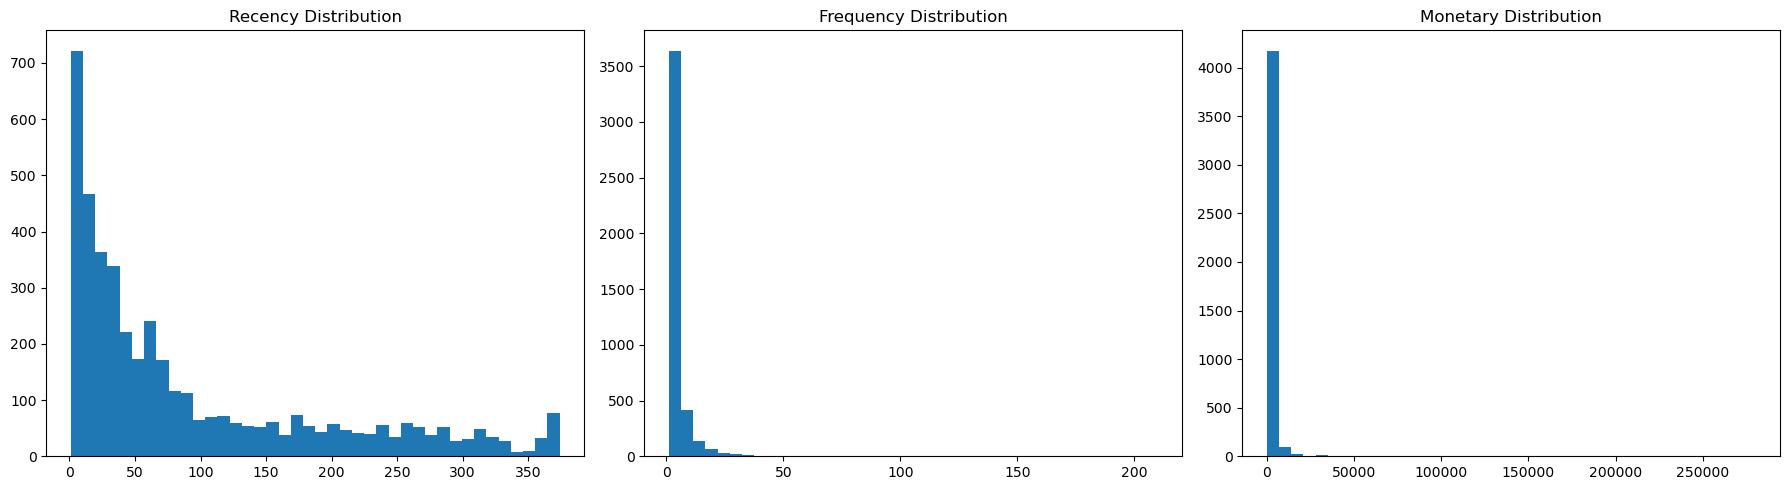

Recency       1.246357
Frequency    12.100028
Monetary     19.326987
dtype: float64


In [46]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=40)
axes[0].set_title('Recency Distribution')

# Frequency
axes[1].hist(rfm['Frequency'], bins=40)
axes[1].set_title('Frequency Distribution')

# Monetary
axes[2].hist(rfm['Monetary'], bins=40)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

print(rfm[['Recency','Frequency','Monetary']].skew())

Histograms of the RFM variables reveal substantial right-skewness, particularly for Frequency and Monetary. The majority of customers exhibit low purchase frequency and low spending levels, while a small subset contributes disproportionately high revenue.

**Recency = 1.25**

This is moderately right-skewed.

Meaning:

- Most customers purchased recently (low Recency values)

- A smaller number haven’t purchased for a long time

- Long tail of inactive customers

This is normal in retail data.


**Frequency = 12.10**

This is extremely right-skewed.

Meaning:

- Most customers buy only once or twice

- Very few customers buy many times

- A handful of "super customers" create a long right tail

This is very common in transactional datasets.

**Monetary = 19.33**

This is extremely extremely skewed.

Meaning:

- Most customers spend small amounts

- Very few customers spend extremely large amounts

- Likely presence of outliers

Example:
*Customer 12346 spent 77,183.60*
That alone contributes to skewness.


### 2. Applying log transformation

Log 1p is used because it handles zero values safely

In [47]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

#### Checking skewness after log transformation

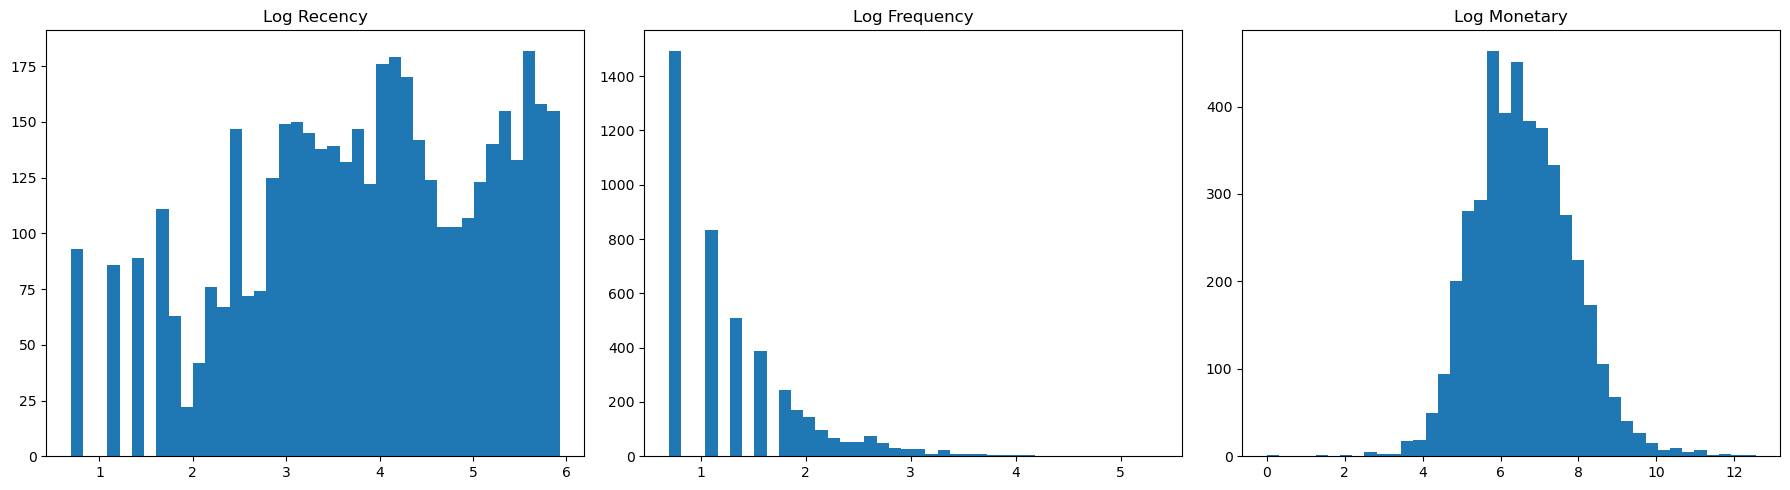

Recency     -0.378677
Frequency    1.208917
Monetary     0.360551
dtype: float64


In [49]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm_log['Recency'], bins=40)
axes[0].set_title('Log Recency')

axes[1].hist(rfm_log['Frequency'], bins=40)
axes[1].set_title('Log Frequency')

axes[2].hist(rfm_log['Monetary'], bins=40)
axes[2].set_title('Log Monetary')

plt.tight_layout()
plt.show()

print (rfm_log[['Recency','Frequency','Monetary']].skew())

Examination of the RFM variables revealed substantial positive skewness, particularly for Frequency (12.10) and Monetary (19.33), indicating the presence of a small number of high-value customers. 

To mitigate the influence of extreme values and improve clustering performance, logarithmic transformation was applied to the RFM features prior to standardization.

Logarithmic transformation significantly reduced skewness in the RFM variables. Frequency decreased from 12.10 to 1.21 and Monetary from 19.33 to 0.36, resulting in distributions that are more symmetric and suitable for distance-based clustering methods such as K-Means.

## **D. CUSTOMER SEGMENTATION**

### 1. Standardize Feautures

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency', 'Frequency', 'Monetary']]
)

### 2. Determine Optimal Number of Clusters (Elbow Method)

c:\Users\Admin\anaconda3\envs\learn-env-py310\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


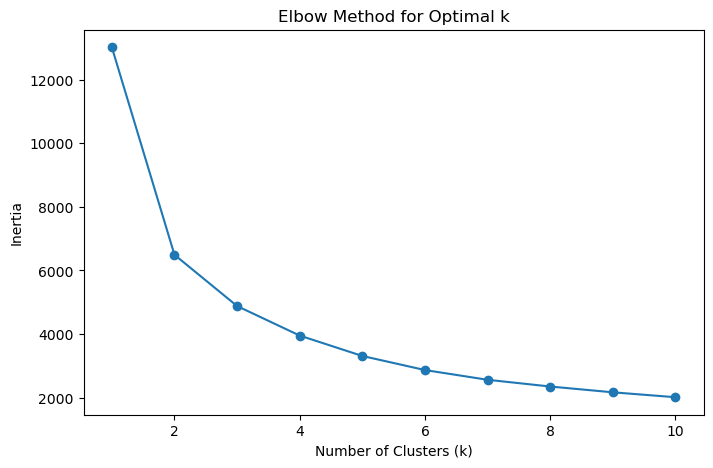

In [51]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

- k=3 looks like the optimal choice. To confirm this Silhouette score is used

### **3. Validate with Silhouette Score**

In [52]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.4327
k=3, Silhouette Score=0.3390
k=4, Silhouette Score=0.3363
k=5, Silhouette Score=0.3161
k=6, Silhouette Score=0.3135
k=7, Silhouette Score=0.3090


**k = 2 gives the highest score (0.4327)**

This means:

- The data naturally separates very clearly into two broad groups

- Cluster compactness and separation are strongest here

**k ≥ 3 lowers the score**

This means:

- Additional clusters reduce separation quality

- The structure becomes less distinct

### **4. Fit Final Model with k = 2**

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)